# Contour Maps

Given a function z = f(x,y) think of a contour map that plots the values of the function on the xy plane. This can be literally an altitude plot in a hilly area.

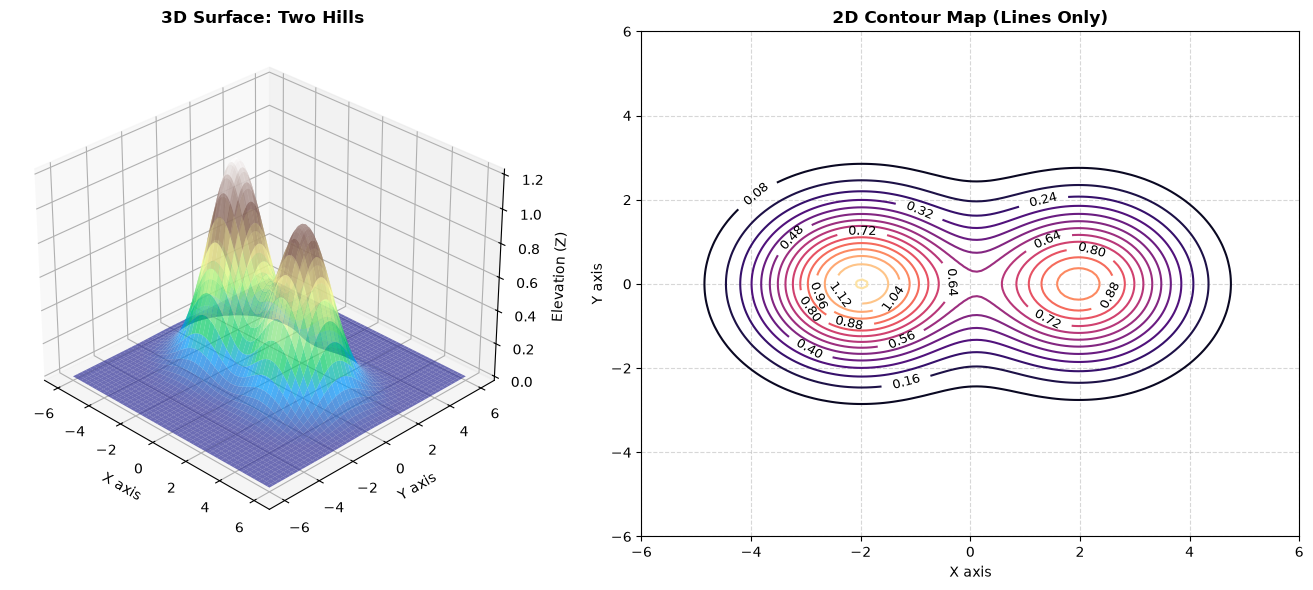

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a mathematical function representing two separate hills
def two_hills(x, y):
    # Hill 1: Centered at (x=2, y=0) with a height factor of 1.0
    hill1 = np.exp(-((x - 2)**2 + y**2) / 3.0)
    # Hill 2: Centered at (x=-2, y=0) with a slightly taller height factor of 1.2
    hill2 = 1.2 * np.exp(-((x + 2)**2 + y**2) / 3.0)
    return hill1 + hill2

# 2. Generate a grid of coordinate pairs
x = np.linspace(-6, 6, 150)
y = np.linspace(-6, 6, 150)
X, Y = np.meshgrid(x, y)
Z = two_hills(X, Y)

# 3. Initialize a figure with side-by-side subplots
fig = plt.figure(figsize=(14, 6))

# Left Plot: 3D Surface View
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# Using a solid color with low alpha to make the wireframe/surface look clean
surf = ax1.plot_surface(X, Y, Z, cmap='terrain', edgecolor='none', alpha=0.7)
ax1.set_title('3D Surface: Two Hills', fontsize=12, fontweight='bold')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Elevation (Z)')
ax1.view_init(elev=30, azim=-45) # Rotates the 3D plot for a clearer view of both peaks

# Right Plot: 2D Contour Map (Lines Only)
ax2 = fig.add_subplot(1, 2, 2)
# .contour() generates wire-lines only instead of solid color blocks (.contourf)
contours = ax2.contour(X, Y, Z, levels=18, cmap='magma', linewidths=1.5)
ax2.set_title('2D Contour Map (Lines Only)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')

# Add inline text labels to the contour lines showing the elevation values
ax2.clabel(contours, inline=True, fontsize=9, fmt='%.2f', colors='black')

# Turn on a subtle grid for the 2D plot background
ax2.grid(True, linestyle='--', alpha=0.5)

# Adjust layout spacing and show plot
plt.tight_layout()
plt.show()


If we look at the contour map, we can see that the directions where lines are closer together reflect steeper "gradients" - where the function increases the fastest. Taking a point p' = (x,y) on the contour map, we can find the point p = (x,y,z) on the surface of the function.

If we take a arbitrary vector in the plane, we want to know how much "height" (i.e. change in f(x,y)) we have for a given vector. 

If we take the tangent at the point p' in the contour map, we get a tangent line - corresponding at p, we have the tangent *plane* $T_p$.  If we draw parallels to the tangent line of p' at a constant distance of 1 unit in the x-y plane, the corresponding lines in the tp-plane are also parallel, but are separated by a constant height difference $\delta{h}$ - but the number of lines pierces remains the same.

$$\zeta(\vec{v}) = (\text{ no of lines pierced by } \vec{v}) * \delta{h}$$

This is the one-form of the function f at p, and is basically nothing but the **gradient** of f at the point p. The term $\zeta(\vec{v})$ then becomes the directional derivative of f at v.

So if "no of lines" pierced remains the same, then we have to multiply by $\delta{h}$ to get the total height gained in $T_p$. The difference is this vector is only curring "contour lines" parallel to the tangent at p, and hence is the accurate measure of the rate of increase of height at p, in the direction of v.

The spacing between the lines is effectively dictated by the rate of change of f. The vector represents the direction (displacement) we want to perform, and the number of lines we cut for this vector v is what the one-form of the function represents. Each line represents a "constant" height (so a vector going along a line will basically gain no height. On the other hand, a vector perpendicular to these lines represents the fastest gain of hieght possible - the gradient.

So the one-form of f, df, is a function defined at p, which takes a vector, and returns the height gained, assuming the terrain continues along the tangent plane. 

The contour lines represent the lines of constant height within - a vector along a contour line will gain no height.

The point that the contour lines come closer togther is basically the fairly obvious statement that if the height is increasing more quickly, the projected contour lines will be spaced closely together - if you see the shadow of a ladder, the steeper the ladder, the more closely spaced the steps are in the shadow of the ladder from a light above the ladder. So the closeness of the lines is a measure of the rate of increase of the function.

## Row Vectors, One-forms, Co-and-Contra-Variance

One-forms are basically row-vectors (and hence represent co-vectors in the dual space V* of whatever vector space V you are in).

To take an example of work done on a body under gravity near the face of the earth (assuming g constant), we have the one-form omega, represented by $[0,0,-mg]$ - where mg represents not so much the force, as the "unit work done in taking a body of mass m by one metre"

$\omega(\vec{v}) = \begin{bmatrix} 0 & 0 & -mg \end{bmatrix}\begin{bmatrix} x \\ y \\ h \end{bmatrix} = -mgh$

Suppose we change units from m to cm, we have to adjust mg:

$\omega(\vec{v}) = \begin{bmatrix} 0 & 0 & -\frac{mg}{100} \end{bmatrix}\begin{bmatrix} x \\ y \\ 100h \end{bmatrix} = -mgh$

It's important to see here that the "force" is **covariant** - when units are changed by 1/100, the "force" is also reduced by 1/100. While displacement is **contravariant** - if we change units to 1/100, the displacement increases a 100 times. Their product (in this case the dot product) remains the same!

This highlights an important point. (work done per unit displacement) is a **rate**, though we don't think of Force as a rate, the proper use of it in the work calculation requires this. Rate, density etc are naturally **covariant**. If we think of force as 5N and W = F.d, this only works when all stick to one consistent set of units. Otherwise, this will get us into trouble. A proper formula would be 

work = (work per unit distance) * distance,

So in metres, F = 5Nm/m. But in cm, F = 5Nm/100cm = 5/100 Nm/cm. Without this the change of units work done (in Joules) would change


**Contraction and Dirac's Bra-Kets**

In the multiplication of a row and column vector (2 vectors), are reduced to a scalar. This is called as a **contraction**. 

Note that a dot product is an example of a contraction.
<!-- 
\newcommand{\bra}[1]{\langle#1|}$
\newcommand{\ket}[1]{|#1\rangle}$
\newcommand{\braket}[2]{\langle #1  \text{ } | \text{ } #2 \rangle}$ -->

In Dirac's bra-ket notation, the vector is specified by a **ket**  $\text{ } \ket{\mathbf{v}}$, and a 1-form with a **bra** : $\text{ } \bra{\omega}$

So we can write:

$\omega(\mathbf{v}) = \braket{\omega}{\mathbf{v}}$

## Basis 1-forms

### Dual Basis Vectors

The Kronecker delta - here a mixed (1,1) tensor - this represents one covariant, one contra-variant :

$$
\delta^i_j = 
    \begin{cases}
        1 \text{ if i = j} \\
        0 \text{ if } i \ne j 
    \end{cases}
$$

So we define :

$$\boxed{\quad \omega^i(\mathbf{e_j}) = \delta^i_j \iff \omega^i(\mathbf{v}) = v^i} \quad \text{Dual Basis Vector}$$


Proof:

Note: We are using the summation rules here
a) 
$$
\begin{aligned}
\omega^i(\mathbf{v}) &= \omega^i(v^j\mathbf{e_j})  \quad \text{the } v^je_j \text{ are a sum by convention} \\
        &= v^j\omega^i(\mathbf{e_j}) \quad \text{ this is still a sum } \\
        &= v^j\mathbf{\delta_j^i} \quad \text{ still a sum over j's } \\
        &= v^i
\end{aligned}
$$

### Are these a basis?

Proof: Given any one-form $\phi$, we can write:

$\phi(\mathbf{v}) = \phi(v^j\mathbf{e_j}) = v^j\phi(\mathbf{e_j}) = \omega^j(\mathbf{v})\phi(\mathbf{e_j})$

So we define the components of $\phi$ as $\phi_j = \phi(\mathbf{e_j})$. Then we can write the one-form $\phi$ (remember - a function), as :

$\phi = \phi_j\omega^j = \phi(\mathbf{e_j})\omega^j$

To elaborate: we are saying (using the summation notation) above that:

$\phi(\mathbf(v)) = \phi(\mathbf{e_1})\omega^1(\mathbf{v}) + \dots + \phi(\mathbf{e_n})\omega^n(\mathbf{v})$


# Gradient 

## Gradient - traditional
The gradient of a function f is the vector:

$\nabla f= \begin{bmatrix} \partial_x f \\ \partial_y f\end{bmatrix}$

The vector points in the direction of the greatest increase, and it's magnitude $|\nabla f|$ equals the maximum rate of increase of f with distance as we move in any direction.

Given a vector $\mathbf{v} = \begin{bmatrix} \delta x \\ \delta y\end{bmatrix}$, 

$\delta f \asymp (\partial_x f)\delta x +  (\partial_y f)\delta y = (\nabla f) \cdot \mathbf{v}$

The symbol $\asymp$ means "approaches in the limit". This was expressed as :

$df = (\partial_x f)dx + (\partial_y f)dy$

Where dx and dy were "infinitesimal" values. We know by definition of the dot product that the derivative is largest when $\mathbf{v}$ is parallel to $df$ (here we are thinking of dx and dy as unit vectors), and zero when it is perpendicular.

Note that this works in $R^3$ also. Here there is a whole plane of vectors which are zero (all in the tangent plane).

## Gradient - differential form

The **gradient 1-form df** of a function f is defined by its actions on vectors.

$$\boldsymbol{d}f = \nabla_{\mathbf{v}}f$$

The $\boldsymbol{d}$ is called the **exterior derivative**.

Is this a one form? It is a linear functional. Also the sum of two vectors, and scalar multiplication work as expected. 

You also get the Product Rule (Leibniz Rule):

$$\boldsymbol{d}(fg) = f \boldsymbol{d} g + g \boldsymbol{d} f$$


## Cartesian 1-form Basis $dx^i$

In the definition of gradient above, $dx^i$ is a 1-form.

Note that by our definition, $dx^1$ is the function $f = x_1$

Then:

$dx^1(\mathbf{v}) = \nabla_{\mathbf{v}} x^1 = (\nabla_{v^1\mathbf{e_1} + v^2\mathbf{e_2}}) x^1 = (v^1\partial_{x^1} + v^2\partial_{x^2}) x^1 = v^1$

So the $dx^i$ are one-forms that make a **dual basis** to $\{\mathbf{e_1, e_2} \}$


$$\boxed{(\boldsymbol{d}x^i)\mathbf{e_j} = \delta^i_j} \quad \text{cartesian basis of 1-forms dual to } \{\mathbf{e_1}, \mathbf{e_2}\}$$

It follows that any 1-form can be decomposed as follows:

$$\boxed{\phi = \phi_jw^j = \phi(\mathbf{e_j})\boldsymbol{d}x^j } \quad \text{decomposition into cartesian basis}$$

## Adding 1-forms Geometrically

What does it mean when we see a 1-form like: dx + dy?

These are just the regular level sets 1 unit apart.

What about 2dx + dy? 

Remember the basis vectors of the dual are "contra-positive" - because these are the "rulers' of the level sets! So 2dx => levels sets distance becomes 1/2. We are compressing the x-axis level sets - they come closer together, so the same vector now cuts double of dx. Also, the x-axis level sets are closer than the y's, so you end up slanting the coordinate system.